# 02 — K-Nearest Neighbors (KNN)

## Theory

KNN is the simplest classifier conceptually: it stores the entire training
set and has **no explicit training phase** ("lazy learning"). To classify a
new point `x`, it:

1. Computes the distance from `x` to every training point (commonly
   **Euclidean**, a special case of the **Minkowski distance**
   $d(x, x') = \big(\sum_i |x_i - x_i'|^p\big)^{1/p}$ with `p=2`).
2. Finds the `k` closest training points.
3. Predicts the **majority class** among those `k` neighbors (optionally
   weighted by inverse distance, so closer neighbors count more).

**Why scaling is critical:** distance is computed across all features at
once, so `Credit amount` — which runs into the thousands — would single-
handedly dictate which applicants count as "neighbors", drowning out `Age`,
`Duration` and every 0/1 one-hot column, unless every feature is first put
on the same scale.

**The curse of dimensionality:** as the number of features grows, all
points tend to become roughly equidistant from each other, and "nearest"
stops being meaningful. KNN works best with a moderate number of informative
features, and one-hot encoding puts some pressure on that here: 9 raw
predictors become 21 columns, 17 of them sparse binaries. Two applicants who
differ only in loan `Purpose` sit a fixed distance apart no matter how
similar the rest of their profile is — one reason to expect KNN to trail the
tree ensembles on this dataset.

**`k` is the central bias-variance knob:**
- Small `k` (e.g. `k=1`) → the decision boundary hugs individual training
  points → **low bias, high variance** (overfitting; noisy/non-smooth
  boundary).
- Large `k` → predictions average over many neighbors → **high bias, low
  variance** (oversmoothed boundary; in the extreme, `k = N` always predicts
  the majority class).


In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


--- KNN (k=5 baseline) ---
              precision    recall  f1-score   support

   good risk       0.74      0.86      0.79       140
    bad risk       0.47      0.30      0.37        60

    accuracy                           0.69       200
   macro avg       0.61      0.58      0.58       200
weighted avg       0.66      0.69      0.67       200

ROC-AUC: 0.709


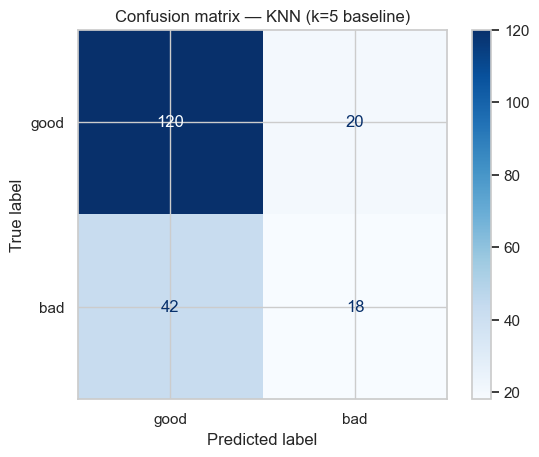

In [7]:
from sklearn.neighbors import KNeighborsClassifier

baseline = KNeighborsClassifier(n_neighbors=5)
baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_test_scaled)
y_proba = baseline.predict_proba(X_test_scaled)[:, 1]
evaluate(baseline, X_test_scaled, y_test, y_pred, y_proba, label="KNN (k=5 baseline)")


## Regularization — `k` (and distance weighting)

KNN has no explicit penalty term like Logistic Regression's L1/L2, but `k`
plays exactly the same role: it's the knob that trades bias for variance.
Sweeping `k` and plotting train vs. test accuracy produces the same
underfitting/overfitting curve we'll see for every model in this project.

We also compare `weights="uniform"` (every neighbor votes equally) against
`weights="distance"` (closer neighbors get more say) — a second, milder form
of regularization that can help when the `k` neighbors aren't all equally
relevant.


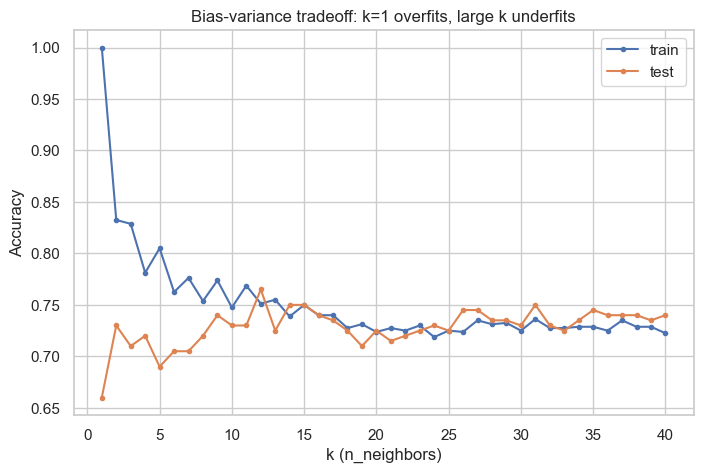

In [8]:
from sklearn.metrics import accuracy_score

ks = np.arange(1, 41)
train_acc, test_acc = [], []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(ks, train_acc, marker=".", label="train")
plt.plot(ks, test_acc, marker=".", label="test")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Bias-variance tradeoff: k=1 overfits, large k underfits")
plt.legend()
plt.show()


As expected: `k=1` memorizes the training set (train accuracy near-perfect)
but generalizes worse than moderate `k`; test accuracy typically peaks
somewhere in a middle range and then degrades again as `k` grows large
enough to oversmooth the boundary.


## Hyperparameter tuning theory

**Hyperparameters** (e.g. `C`, `max_depth`, `n_neighbors`) are settings chosen
*before* training, unlike model *parameters* (e.g. logistic regression's
weights) which are learned *from* the data. Picking hyperparameters by
checking performance on the test set would leak information from the test
set into modeling decisions, silently inflating our estimate of how well the
model generalizes.

The fix is **k-fold cross-validation**: split the training data into `k`
folds, train on `k-1` of them and validate on the remaining fold, rotate
which fold is held out, and average the `k` validation scores. This gives a
more reliable performance estimate for *each* candidate hyperparameter
setting, all without ever touching the test set. The test set is only used
once, at the very end, to report a final, honest number.

- **Grid search** exhaustively tries every combination of the specified
  hyperparameter values. Simple and reproducible, but the number of
  combinations grows exponentially with the number of hyperparameters.
- **Random search** samples a fixed number of random combinations. Often
  finds a near-optimal setting far faster than grid search when several
  hyperparameters barely matter, because it doesn't waste evaluations
  repeating values for the unimportant ones.

We use `GridSearchCV` when the search space is small enough to be exhaustive,
and `RandomizedSearchCV` when it isn't.


Best params: {'n_neighbors': np.int64(39), 'p': 2, 'weights': 'distance'}
Best CV ROC-AUC: 0.731
--- KNN (tuned) ---
              precision    recall  f1-score   support

   good risk       0.75      0.97      0.84       140
    bad risk       0.78      0.23      0.36        60

    accuracy                           0.75       200
   macro avg       0.76      0.60      0.60       200
weighted avg       0.76      0.75      0.70       200

ROC-AUC: 0.723


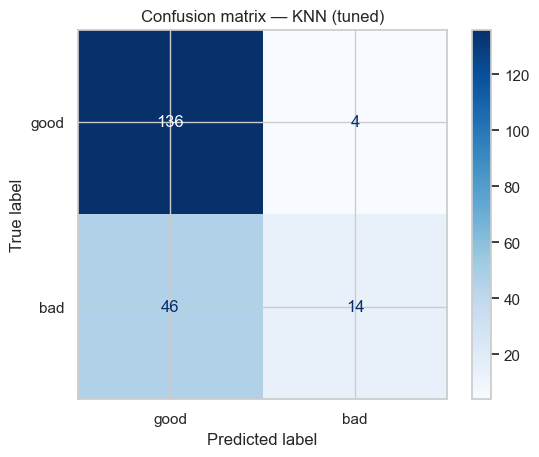

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": np.arange(1, 41, 2),
    "weights": ["uniform", "distance"],
    "p": [1, 2],  # Manhattan vs. Euclidean distance
}

grid = GridSearchCV(
    KNeighborsClassifier(), param_grid=param_grid, scoring="roc_auc", cv=5, n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
evaluate(best_knn, X_test_scaled, y_test, y_pred, y_proba, label="KNN (tuned)")


## Decision threshold tuning

Every classifier we use here can produce a **predicted probability** `P(bad | x)`
in addition to a hard label. Scikit-learn's `.predict()` turns that probability
into a 0/1 label by applying a fixed **threshold of 0.5**: if `P(bad) >= 0.5`
predict "bad risk", otherwise predict "good risk".

0.5 is just a default — it is not guaranteed to be the best cutoff for your
problem, and on this dataset it is almost certainly the wrong one. Two
reasons the optimal threshold can differ from 0.5:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so a model
   has to be unusually confident before `P(bad)` clears 0.5 — the default
   cutoff quietly favours the majority "good" class and suppresses recall on
   the class we actually care about. (Reweighting the loss with
   `class_weight="balanced"` is the other standard lever for this; it shifts
   roughly the same boundary, but requires retraining.)
2. **Asymmetric costs.** A false negative and a false positive rarely cost the
   same in the real world — approving a loan that defaults costs the lender
   the outstanding principal, while declining an applicant who would have
   repaid costs only the foregone interest. Moving the threshold trades
   precision for recall (or vice versa) along the model's ROC /
   precision-recall curve — it does not require retraining the model at all.

Two curves help pick a threshold:

- **ROC curve** — plots True Positive Rate vs. False Positive Rate as the
  threshold sweeps from 1 to 0. **Youden's J statistic** `J = TPR - FPR` is
  maximized at the threshold that best separates the classes when both error
  types are weighted equally.
- **Precision-Recall curve** — plots precision vs. recall as the threshold
  sweeps. More informative than ROC when classes are imbalanced. The
  threshold that maximizes the **F1 score** (harmonic mean of precision and
  recall) is a common choice when you care about both error types but the
  positive class is what matters.

Below we compute both curves, find the Youden's-J-optimal and
F1-optimal thresholds, and compare the resulting metrics against the
default 0.5 cutoff.


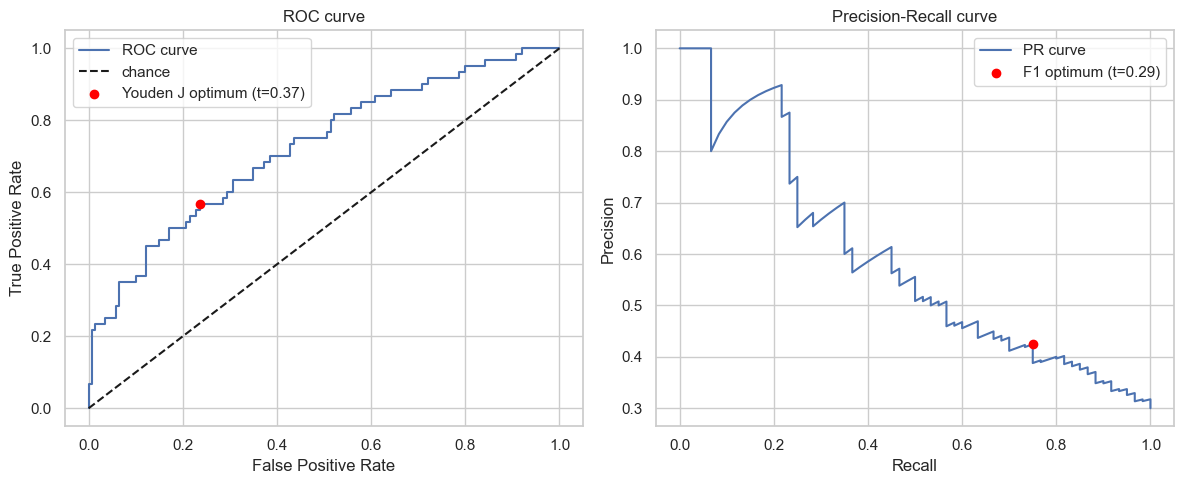

Youden's J optimal threshold: 0.374
F1-optimal threshold:         0.295


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.750,0.777778,0.233333,0.358974
Youden's J,0.373706,0.705,0.507463,0.566667,0.535433
F1-optimal,0.294544,0.620,0.424528,0.750000,0.542169


In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_knn.predict_proba(X_test_scaled)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- `k` is KNN's one true hyperparameter, and it directly controls the
  bias-variance tradeoff — small `k` overfits, large `k` underfits.
- Feature scaling isn't optional here; without it, distance calculations
  are dominated by whichever feature happens to have the largest raw range.
- Cross-validation picked a `k` (and distance metric/weighting) that
  balances the tradeoff better than an arbitrary default.
